In [12]:
import numpy as np
from scipy.io import loadmat
from Neural_Decoding.preprocessing_funcs import bin_spikes, get_spikes_with_history
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter1d

%matplotlib widget

In [13]:
!ls

'7 13 23 OneOnOne.ipynb'		  scrapbook.ipynb
 prelim_multiregion_climbing_opto.ipynb


In [14]:
#Function for reformatting spike times that are saved from matlab
def reformat_spike_times(spike_times):
    spike_times=np.squeeze(spike_times)
    for i in range(spike_times.shape[0]):
        spike_times[i]=np.squeeze(spike_times[i])
    return spike_times

In [15]:
#Load data
data=loadmat('../data/mark_prelim_data_opto.mat')

duration=data['duration'][0][0]
isclimbing=data['isclimbing']
laser=data['laser']

In [16]:
#Say what the region names are in the data
regions=['probe1','probe2']

In [17]:
laser.shape

(1, 3383000)

## Extract time bins of laser data

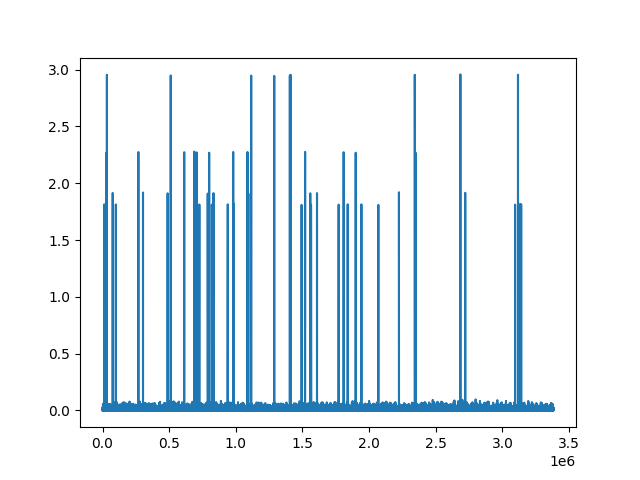

In [18]:
fig, ax = plt.subplots()
ax.plot(laser[0,:])

In [19]:
#Set laser threshold
laser_thresh=0.1

In [20]:
opto_effect_time=50  #Time after the opto to consider

laser_idxs=laser>laser_thresh #When laser is above thresh

#Find start and end of laser
laser_change=laser_idxs[0,1:].astype(int)-laser_idxs[0,:-1].astype(int)
laser_start= laser_change==1
laser_end= laser_change==-1

#Get start/end indices for bins
laser_start_idx= list(np.where(laser_start)[0])
laser_end_idx= list(np.where(laser_end)[0]+opto_effect_time)

num_lasers=len(laser_start_idx)

## Extract spike times

In [21]:
spike_times={}
for r in regions:
    spike_times[r]=reformat_spike_times(data[r+'_spikes'])

In [22]:
spike_times[r][1].shape

(150,)

## Extract times of climbing

In [23]:
climb_change=isclimbing[0][1:].astype(int)-isclimbing[0][:-1].astype(int)

climb_start= climb_change==1
climb_end= climb_change==-1

climb_start_idx= list(np.where(climb_start)[0])
climb_end_idx= list(np.where(climb_end)[0])

num_total_climbs=len(climb_start_idx)

In [24]:
## Finds climbing bouts that did/didn't have opto

climb_opto=[]
climb_no_opto=[]
for c in range(num_total_climbs):
    if np.sum((climb_start_idx[c]<laser_start_idx)*(climb_end_idx[c]>laser_start_idx)):
        climb_opto.append(c)
    else:
        climb_no_opto.append(c)

In [25]:
print(len(climb_opto))
print(len(climb_no_opto))

34
93


In [26]:
duration

3383000

In [27]:
dt=5 #Time bins
t_start=0
# t_end=duration

fr_thresh=.5

# sig=25/dt #For smoothing

In [28]:
binned_data={}
for r in regions:
    binned_data[r]=[bin_spikes(spike_times[r],dt,climb_start_idx[c],climb_end_idx[c]) for c in range(num_total_climbs)]

# binned_data2={}
# for r in regions:
#     binned_data2[r]=[bin_spikes(spike_times[r],dt,climb_start_idx[c],climb_end_idx[c]) for c in climb_opto]
    
# binned_data3={}
# for r in regions:
#     binned_data3[r]=[bin_spikes(spike_times[r],dt,laser_start_idx[c],laser_end_idx[c]) for c in range(num_lasers)]

In [29]:
frs={}
for r in regions:
    frs[r]=np.mean(np.vstack(binned_data[r]),axis=0)*1000/dt

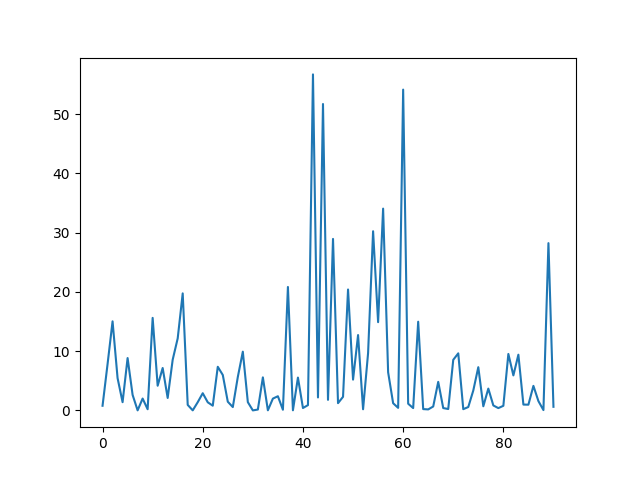

In [30]:
fig1, ax1 = plt.subplots()
ax1.plot(frs['probe1'])

In [31]:
#Which neurons to include

inc_nrns={}
for r in regions:
    inc_nrns[r]=frs[r]>fr_thresh

In [32]:
binned_data_inc={}
for r in regions:
    binned_data_inc[r]=[binned_data[r][c][:,inc_nrns[r]] for c in range(num_total_climbs)]

In [34]:
#smoothed_data_inc={}
#for r in regions:
#    smoothed_data_inc[r]=[gaussian_filter1d(binned_data_inc[r][c].astype(float), sig,axis=0,mode='constant') for c in range(num_total_climbs)]

NameError: name 'sig' is not defined

In [44]:
stacked_binned_data_inc={}
for r in regions:
    stacked_binned_data_inc[r]=np.vstack(binned_data_inc[r])

# stacked_smoothed_data_inc={}
# for r in regions:
#     stacked_smoothed_data_inc[r]=np.vstack(smoothed_data_inc[r])

In [45]:
#Test PCA

pcas_test={}
for r in regions:
    pcas_test[r]=PCA(n_components=stacked_binned_data_inc[r].shape[1])
#     pcas_test[r].fit(stacked_smoothed_data_inc[r])
    pcas_test[r].fit(stacked_binned_data_inc[r])
    

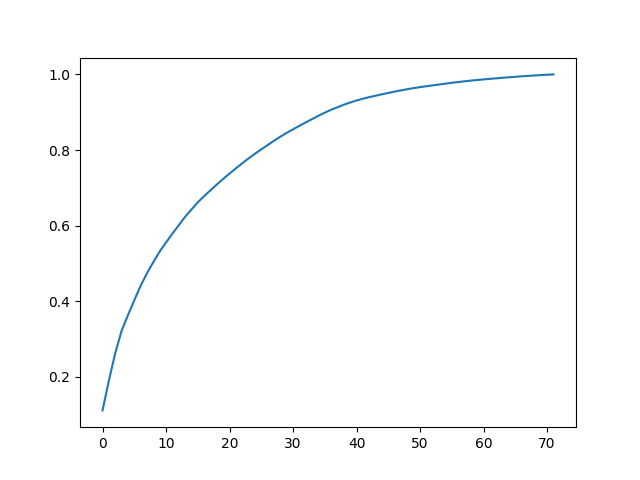

In [22]:
fig2, ax2 = plt.subplots()
ax2.plot(np.cumsum(pcas_test['probe1'].explained_variance_ratio_))

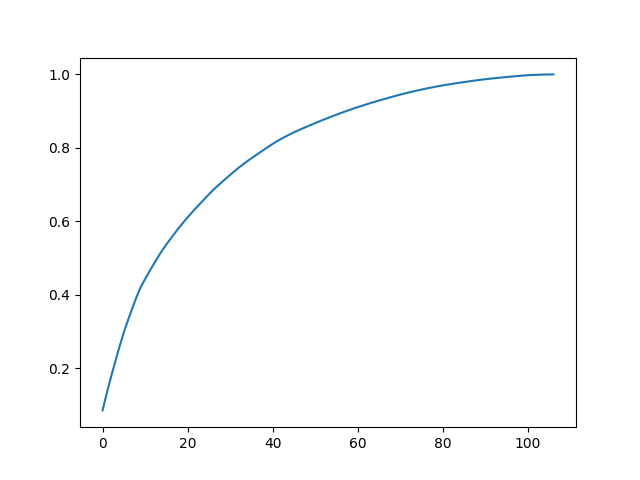

In [23]:
fig3, ax3 = plt.subplots()
ax3.plot(np.cumsum(pcas_test['probe2'].explained_variance_ratio_))